In [82]:
%matplotlib inline

In [83]:
!pip install -q datasets streamlit pandas matplotlib seaborn
!npm install -g localtunnel


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
'npm' is not recognized as an internal or external command,
operable program or batch file.


In [84]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

In [85]:
sst2 = load_dataset("nyu-mll/glue", "sst2")
mrpc = load_dataset("nyu-mll/glue", "mrpc")

mrpc_train = mrpc['train']
mrpc_test = mrpc['test']

sst2_train = sst2['train']
sst2_test = sst2['test']

In [86]:
print(sst2_train[:5])
print(sst2_test[:5])

{'sentence': ['hide new secretions from the parental units ', 'contains no wit , only labored gags ', 'that loves its characters and communicates something rather beautiful about human nature ', 'remains utterly satisfied to remain the same throughout ', 'on the worst revenge-of-the-nerds clichés the filmmakers could dredge up '], 'label': [0, 0, 1, 0, 0], 'idx': [0, 1, 2, 3, 4]}
{'sentence': ['uneasy mishmash of styles and genres .', "this film 's relationship to actual tension is the same as what christmas-tree flocking in a spray can is to actual snow : a poor -- if durable -- imitation .", 'by the end of no such thing the audience , like beatrice , has a watchful affection for the monster .', 'director rob marshall went out gunning to make a great one .', 'lathan and diggs have considerable personal charm , and their screen rapport makes the old story seem new .'], 'label': [-1, -1, -1, -1, -1], 'idx': [0, 1, 2, 3, 4]}


In [87]:
sst2_train = pd.DataFrame(sst2_train)
sst2_test = pd.DataFrame(sst2_test)
mrpc_train = pd.DataFrame(mrpc_train)
mrpc_test = pd.DataFrame(mrpc_test)

In [88]:
sst2_train.head()

,sentence,label,idx
0,hide new secretions from the parental units,0,0
1,"contains no wit , only labored gags",0,1
2,that loves its characters and communicates som...,1,2
3,remains utterly satisfied to remain the same t...,0,3
4,on the worst revenge-of-the-nerds clichés the ...,0,4


In [89]:
sst2_test.head()

,sentence,label,idx
0,uneasy mishmash of styles and genres .,-1,0
1,this film 's relationship to actual tension is...,-1,1
2,"by the end of no such thing the audience , lik...",-1,2
3,director rob marshall went out gunning to make...,-1,3
4,lathan and diggs have considerable personal ch...,-1,4


In [90]:
mrpc_train.head()

,sentence1,sentence2,label,idx
0,"Amrozi accused his brother , whom he called "" ...","Referring to him as only "" the witness "" , Amr...",1,0
1,Yucaipa owned Dominick 's before selling the c...,Yucaipa bought Dominick 's in 1995 for $ 693 m...,0,1
2,They had published an advertisement on the Int...,"On June 10 , the ship 's owners had published ...",1,2
3,"Around 0335 GMT , Tab shares were up 19 cents ...","Tab shares jumped 20 cents , or 4.6 % , to set...",0,3
4,"The stock rose $ 2.11 , or about 11 percent , ...",PG & E Corp. shares jumped $ 1.63 or 8 percent...,1,4


In [91]:
mrpc_test.head()

,sentence1,sentence2,label,idx
0,"PCCW 's chief operating officer , Mike Butcher...",Current Chief Operating Officer Mike Butcher a...,1,0
1,The world 's two largest automakers said their...,Domestic sales at both GM and No. 2 Ford Motor...,1,1
2,According to the federal Centers for Disease C...,The Centers for Disease Control and Prevention...,1,2
3,A tropical storm rapidly developed in the Gulf...,A tropical storm rapidly developed in the Gulf...,0,3
4,The company didn 't detail the costs of the re...,But company officials expect the costs of the ...,0,4


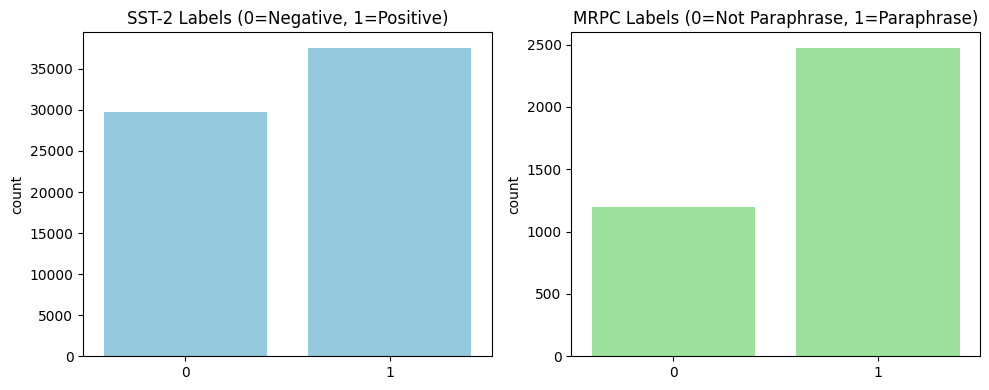

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(x=sst2['train']['label'], ax=axes[0], color='skyblue')
axes[0].set_title('SST-2 Labels (0=Negative, 1=Positive)')

sns.countplot(x=mrpc['train']['label'], ax=axes[1], color='lightgreen')
axes[1].set_title('MRPC Labels (0=Not Paraphrase, 1=Paraphrase)')

plt.tight_layout()
plt.show()

In [94]:
import re
from collections import Counter

def simple_tokenizer(text):
    return re.findall(r'\b\w+\b', text.lower())

word_counts = Counter()

for text in sst2_train['sentence']:
    word_counts.update(simple_tokenizer(text))

for text in mrpc_train['sentence1']:
    word_counts.update(simple_tokenizer(text)) 

for text in mrpc_train['sentence2']:
    word_counts.update(simple_tokenizer(text))

In [95]:
print(len(word_counts))

21370


In [97]:
print(word_counts.values())

dict_values([15, 1041, 3, 2528, 35937, 8, 9, 28, 1323, 213, 859, 35, 123, 8964, 39, 4283, 1137, 23020, 10, 680, 356, 264, 2154, 394, 121, 139, 98, 34, 16364, 64, 293, 101, 3870, 279, 47, 21599, 21, 122, 190, 691, 13, 1619, 10646, 433, 1370, 93, 42, 623, 73, 94, 25, 769, 430, 19, 5743, 11, 52, 1111, 534, 171, 1622, 24904, 228, 144, 4070, 5550, 4651, 322, 22, 9, 19, 21, 885, 685, 8, 81, 2221, 2398, 204, 176, 748, 2274, 10752, 1632, 368, 101, 548, 213, 50, 13, 5246, 512, 50, 1648, 10, 1024, 751, 2393, 2535, 838, 685, 1894, 123, 10, 310, 363, 525, 42, 66, 592, 980, 3696, 3739, 1783, 8, 1072, 43, 167, 1420, 105, 28, 161, 2355, 118, 274, 58, 30, 137, 8, 9621, 176, 1953, 314, 196, 265, 2964, 80, 100, 233, 26, 10, 9, 7824, 71, 9, 344, 141, 1048, 6, 1204, 289, 596, 2, 174, 1, 24, 4, 20, 35, 4, 48, 53, 8, 95, 992, 329, 18, 11, 585, 17, 112, 9, 4, 16, 14, 65, 510, 11, 45, 1077, 333, 20, 129, 2278, 570, 355, 957, 1523, 78, 37, 569, 3087, 10, 95, 44, 730, 28, 19, 1465, 336, 943, 239, 496, 49, 106, 

In [96]:
print(sum(word_counts.values()))

743840


In [102]:
MAX_VOCAB_SIZE = 8000
most_common_words = word_counts.most_common(MAX_VOCAB_SIZE)

In [ ]:
print(most_common_words[:100])  

[('the', 35937), ('a', 24904), ('and', 23020), ('of', 21599), ('to', 16364), ('in', 10752), ('s', 10646), ('is', 9621), ('that', 8964), ('it', 7824), ('as', 5743), ('with', 5550), ('for', 5246), ('an', 4651), ('its', 4283), ('film', 4070), ('on', 3870), ('movie', 3739), ('this', 3696), ('be', 3306), ('but', 3087), ('by', 2964), ('at', 2930), ('you', 2843), ('t', 2535), ('from', 2528), ('has', 2456), ('more', 2398), ('not', 2394), ('n', 2393), ('one', 2390), ('his', 2355), ('or', 2278), ('than', 2274), ('are', 2221), ('have', 2156), ('about', 2154), ('all', 1953), ('so', 1896), ('like', 1894), ('said', 1840), ('was', 1783), ('who', 1648), ('most', 1632), ('out', 1622), ('up', 1619), ('good', 1523), ('into', 1473), ('will', 1465), ('he', 1457), ('story', 1420), ('i', 1389), ('too', 1370), ('no', 1323), ('if', 1204), ('their', 1201), ('time', 1171), ('funny', 1161), ('just', 1143), ('characters', 1137), ('can', 1111), ('comedy', 1107), ('been', 1097), ('well', 1088), ('what', 1082), ('whi

In [115]:
from gensim.models import Word2Vec
import numpy as np

# Tokenize datasets
sst2_tokens = [
    simple_tokenizer(text)
    for text in sst2_train["sentence"]
]

mrpc_tokens = [
    simple_tokenizer(s1) + simple_tokenizer(s2)
    for s1, s2 in zip(mrpc_train["sentence1"], mrpc_train["sentence2"])
]

# Combine all sentences
all_tokens = sst2_tokens + mrpc_tokens

print("Total sentences:", len(all_tokens))

# Train Word2Vec
w2v_model = Word2Vec(
    sentences=all_tokens,
    vector_size=300,
    window=5,
    min_count=2,
    workers=2
)

# Build vocabulary
word2idx = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word in w2v_model.wv.key_to_index:
    word2idx[word] = len(word2idx)

vocab_size = len(word2idx)
embed_dim = w2v_model.vector_size

# Create embedding matrix
embedding_matrix = np.zeros((vocab_size, embed_dim))

for word, idx in word2idx.items():
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]

print("Vocabulary Size:", vocab_size)
print("Embedding Dimension:", embed_dim)
print("Embedding Matrix Shape:", embedding_matrix.shape)

Total sentences: 71017
Vocabulary Size: 18680
Embedding Dimension: 300
Embedding Matrix Shape: (18680, 300)


In [116]:
MAX_LEN = 50

def text_to_indices(text):
    tokens = simple_tokenizer(text)
    indices = [word2idx.get(word, 1) for word in tokens]

    if len(indices) < MAX_LEN:
        indices += [0] * (MAX_LEN - len(indices))
    else:
        indices = indices[:MAX_LEN] # Truncate

    return indices


In [120]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

class MultiTaskRNNDataset(Dataset):

    def __init__(self):

        self.data = []

        # SST-2
        for i in range(len(sst2_train)):

            text = sst2_train.iloc[i]["sentence"]
            label = sst2_train.iloc[i]["label"]

            self.data.append(
                (text_to_indices(text), label, 0)
            )

        # MRPC
        for i in range(len(mrpc_train)):

            text = (
                mrpc_train.iloc[i]["sentence1"]
                + " " +
                mrpc_train.iloc[i]["sentence2"]
            )

            label = mrpc_train.iloc[i]["label"]

            self.data.append(
                (text_to_indices(text), label, 1)
            )

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        ids, label, task_id = self.data[idx]

        return {
            "input_ids": torch.tensor(ids, dtype=torch.long),
            "label": torch.tensor(label, dtype=torch.long),
            "task_id": torch.tensor(task_id, dtype=torch.long)
        }


dataset = MultiTaskRNNDataset()

dataset = torch.utils.data.Subset(
    dataset,
    range(min(15000, len(dataset)))
)

dataloader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

print(f"Dataset ready! Training on {len(dataset)} samples.")

Dataset ready! Training on 15000 samples.


In [121]:
class MultiTaskRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, embedding_matrix=None, freeze_embeddings=True):
        super(MultiTaskRNN, self).__init__()

        # 1. Embedding layer
        if embedding_matrix is not None:
            # Convert numpy array to torch tensor
            embedding_tensor = torch.tensor(embedding_matrix, dtype=torch.float)
            self.embedding = nn.Embedding.from_pretrained(embedding_tensor, freeze=freeze_embeddings, padding_idx=0)
        else:
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # 2. The RNN (LSTM)
        self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)

        # 3. Task-Specific Heads
        self.head_sst2 = nn.Linear(hidden_dim, 2)  # Sentiment
        self.head_mrpc = nn.Linear(hidden_dim, 2)  # Paraphrase

    def forward(self, input_ids, task_ids):
        embedded = self.embedding(input_ids)
        out, (hidden, cell) = self.rnn(embedded)

        # Get the last hidden state
        last_hidden_state = out[:, -1, :]

        # Route to the correct task head
        logits = []
        batch_size = input_ids.size(0)

        for i in range(batch_size):
            if task_ids[i] == 0:
                logits.append(self.head_sst2(last_hidden_state[i]))
            else:
                logits.append(self.head_mrpc(last_hidden_state[i]))

        return torch.stack(logits)

print("Model architecture defined successfully!")

Model architecture defined successfully!


In [124]:
import json

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

HIDDEN_DIM = 128
model = MultiTaskRNN(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    hidden_dim=HIDDEN_DIM,
    embedding_matrix=embedding_matrix
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.003) # Slightly lower LR since embeddings are pre-trained

epochs = 5
print(f"\nStarting training for {epochs} epochs...")

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in dataloader:
        input_ids = batch['input_ids'].to(device)
        labels = batch['label'].to(device)
        task_ids = batch['task_id'].to(device)

        optimizer.zero_grad()
        predictions = model(input_ids, task_ids)
        loss = criterion(predictions, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

# Save model and embedding matrix for Streamlit
torch.save(model.state_dict(), 'data/w2v_rnn_model.pt')
np.save('data/embedding_matrix.npy', embedding_matrix)

# Save vocab as JSON
with open('data/vocab.json', 'w') as f:
    json.dump(word2idx, f)

print("\n✅ Training complete! Artifacts saved.")

Training on: cpu

Starting training for 5 epochs...
Epoch 1/5 | Loss: 0.6879
Epoch 2/5 | Loss: 0.6877
Epoch 3/5 | Loss: 0.6877
Epoch 4/5 | Loss: 0.6875
Epoch 5/5 | Loss: 0.6877

✅ Training complete! Artifacts saved.


In [125]:
import tensorflow as tf
import numpy as np

MAX_LEN = 50

def text_to_indices(text):

    tokens = simple_tokenizer(text)

    indices = [word2idx.get(word, word2idx["<UNK>"]) for word in tokens]

    if len(indices) < MAX_LEN:
        indices += [word2idx["<PAD>"]] * (MAX_LEN - len(indices))
    else:
        indices = indices[:MAX_LEN]

    return indices


input_ids = []
labels = []
task_ids = []

# SST-2
for _, row in sst2_train.iterrows():

    input_ids.append(text_to_indices(row["sentence"]))
    labels.append(row["label"])
    task_ids.append(0)

# MRPC
for _, row in mrpc_train.iterrows():

    text = row["sentence1"] + " " + row["sentence2"]

    input_ids.append(text_to_indices(text))
    labels.append(row["label"])
    task_ids.append(1)

input_ids = np.array(input_ids)
labels = np.array(labels)
task_ids = np.array(task_ids)

limit = min(15000, len(input_ids))

input_ids = input_ids[:limit]
labels = labels[:limit]
task_ids = task_ids[:limit]

print(input_ids.shape)
print(labels.shape)
print(task_ids.shape)

(15000, 50)
(15000,)
(15000,)


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Lambda
from tensorflow.keras.models import Model

HIDDEN_DIM = 128

# Inputs
text_input = Input(
    shape=(MAX_LEN,),
    name="input_ids"
)

task_input = Input(
    shape=(1,),
    dtype="int32",
    name="task_id"
)

# Embedding
embedding = Embedding(
    input_dim=vocab_size,
    output_dim=embed_dim,
    weights=[embedding_matrix],
    trainable=False,
    mask_zero=True
)(text_input)

# Shared RNN
shared_features = SimpleRNN(
    HIDDEN_DIM
)(embedding)

# Task-specific heads
sst2_logits = Dense(
    2,
    name="sst2_head"
)(shared_features)

mrpc_logits = Dense(
    2,
    name="mrpc_head"
)(shared_features)

def select_head(inputs):

    sst2, mrpc, task = inputs

    task = tf.cast(task, tf.int32)

    return tf.where(
        tf.equal(task, 0),
        sst2,
        mrpc
    )

output = Lambda(
    select_head,
    name="output"
)([sst2_logits, mrpc_logits, task_input])

model = Model(
    inputs=[text_input, task_input],
    outputs=output
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50, 300)   │  5,604,000 │ input_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 50)        │          0 │ input_ids[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 128)       │     54,912 │ embedding[0][0],  │
│ (SimpleRNN)         │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sst2_head (Dense)   │ (None, 2)         │        258 │ simple_rnn[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mrpc_head (Dense)   │ (None, 2)         │        258 │ simple_rnn[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ task_id             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Lambda)     │ (None, 2)         │          0 │ sst2_head[0][0],  │
│                     │                   │            │ mrpc_head[0][0],  │
│                     │                   │            │ task_id[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,659,428 (21.59 MB)

 Trainable params: 55,428 (216.52 KB)

 Non-trainable params: 5,604,000 (21.38 MB)

In [127]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.003
    ),

    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),

    metrics=["accuracy"]
)

history = model.fit(

    x={
        "input_ids": input_ids,
        "task_id": task_ids
    },

    y=labels,

    batch_size=64,

    epochs=5,

    shuffle=True
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.5971 - loss: 0.6739
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.6423 - loss: 0.6260
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.6691 - loss: 0.5992
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.6891 - loss: 0.5752
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.7087 - loss: 0.5588


In [128]:
model.save("data/w2v_rnn.keras")

np.save(
    "data/embedding_matrix.npy",
    embedding_matrix
)

import json

with open("data/vocab.json", "w") as f:
    json.dump(word2idx, f)

print("Training Complete!")

Training Complete!
